## **Estimating Total Factor Productivity**

## **1. Setup**

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import minimize_scalar, minimize
import seaborn as sns

parent_dir = Path.cwd().parent
sys.path.append(f'{parent_dir}/py_modules')

from capital_est_modules import reset_diff_on_drop, capital_measures, fixed_effects_model, decomposition, TFP_plot
import OP_model
import ACF_model
import ACF_full as acf

## **2. Load Data**

In [2]:
financial_data = pd.read_excel(f'{parent_dir}/output/Quarterly Data (with Employees).xlsx')

### **2.1. Set up variables and data**

#### **Time variables and value added**

In [3]:
unique_years = sorted(list(financial_data['Fiscal Data Year and Quarter'].unique()))
year_categories = range(1, len(unique_years) + 1)

mapping_dict = dict(zip(unique_years, year_categories))
financial_data = financial_data.copy()
financial_data['time'] = financial_data['Fiscal Data Year and Quarter'].map(mapping_dict)

time_col = financial_data.pop('time')
financial_data.insert(2, 'time', time_col)

In [4]:
financial_data['Value Added'] = financial_data['Revenue - Total'] - financial_data['Cost of Goods Sold']

#### **Survival variable for the Olley-Pakes model**

In [5]:
MAX_TIME = financial_data['time'].max()                                                                                                                                         
                                                                                                                                                                                
def flag_exit(df):                                                                                                                                                              
    df = df.sort_values('time').copy()
    df['Survival'] = 1
    if df['time'].iloc[-1] != MAX_TIME:                                                                                                                                         
        df.iloc[-1, df.columns.get_loc('Survival')] = 0
    return df                                                                                                                                                                   
                                                                                                                                                                                
financial_data['Ticker Symbol 1'] = financial_data['Ticker Symbol']
financial_data = (financial_data
                .groupby('Ticker Symbol 1', group_keys=False)                                                                                                                   
                .apply(flag_exit))

#### **Model-Agnostic Variables & Clean-Up**

In [6]:
# Set Up Production Function Variables
identifiers = ['Ticker Symbol',
               'Fiscal Year',
               'time', 
               'Date',
               'NAICS Industry']

output = ['Revenue - Total', 'Value Added']

physical_capital = ['Property, Plant and Equipment - Total (Gross)',
                    'Inventories - Total',
                    'Working Capital (Balance Sheet)']

non_physical_capital = ['Intangible Assets - Total']

depreciation_cols = ['Depreciation, Depletion and Amortization (Accumulated)',
                     'Depreciation and Amortization']

labor = ['Employees_pred_point', 'Employees_pred_lower', 'Employees_pred_upper']

additional_input_variable = ['Inventory - Raw Materials', 'Cost of Goods Sold']

survival = ['Survival']

cols = identifiers + output + physical_capital + non_physical_capital + depreciation_cols + labor + additional_input_variable + survival

financial_data = financial_data[cols]

financial_data['Physical Capital'] = financial_data[physical_capital].sum(axis=1)
financial_data['Non-Physical Capital'] = financial_data[non_physical_capital].sum(axis=1)
financial_data['PC & NPC'] = financial_data['Physical Capital'] + financial_data['Non-Physical Capital']

In [7]:
financial_data = financial_data.rename(columns={'Employees_pred_point': 'Total Employment',
                                                'Fiscal Year': 'year'})

financial_data = financial_data[financial_data['Total Employment'].notna()]
financial_data = financial_data[financial_data['Depreciation, Depletion and Amortization (Accumulated)'].notna()]
financial_data['Ticker Symbol'].astype(str)

financial_data['Depreciation, Depletion and Amortization (Accumulated)'] = pd.to_numeric(
        financial_data['Depreciation, Depletion and Amortization (Accumulated)'], errors='coerce')


In [8]:
missing_values = pd.DataFrame(financial_data.isna().sum())

missing_values.rename(columns={0: 'Missing Values'}, inplace=True)
missing_values[missing_values != 0].dropna()

,Missing Values
Inventory - Raw Materials,1165.0


In [9]:
financial_data = financial_data.dropna()

In [10]:
financial_data = financial_data[(financial_data['Revenue - Total'] > 0)
                                & (financial_data['Value Added'] > 0)
                                & (financial_data['Cost of Goods Sold'] > 0)
                                & (financial_data['PC & NPC'] > 0)
                                & (financial_data['Total Employment'] > 0)
                                & (financial_data['time'].notna())]

In [11]:
symbols = list(financial_data['Ticker Symbol'].unique())

dfs = {}
for symbol in symbols:
    dfs[symbol] = financial_data[financial_data['Ticker Symbol'] == symbol].copy()

#### **Calculate Lagged Investment & Capital**

In [12]:
target_col = 'Depreciation, Depletion and Amortization (Accumulated)'

for symbol, df in dfs.items():
    # Find the index of the first non-NaN value in the target column
    first_valid_index = df[target_col].first_valid_index()

    # If a valid index exists, trim the DataFrame starting from that row
    if first_valid_index is not None:
        dfs[symbol] = df.loc[first_valid_index:].reset_index(drop=True)

In [13]:
capital_measures(dfs, 'PC & NPC', 1, 0)
capital_measures(dfs, 'PC & NPC', 2, 3)

In [14]:
financial_data = pd.DataFrame()

for df in dfs.values():
    financial_data = pd.concat([financial_data, df])

In [15]:
capital1 = financial_data
capital2 = financial_data[financial_data['Capital Measure 2'] > 0]

#### **Log-Transformation**

In [16]:
capital1 = capital1.copy()
capital2 = capital2.copy()

cols_to_log = ['Revenue - Total',
               'Cost of Goods Sold',
               'Total Employment',
               'Employees_pred_lower', 
               'Employees_pred_upper',
               'Capital Measure 1',
               'Capital Measure 2',
               'Capital Expenditure',
               'Inventory - Raw Materials',
               'Value Added']

capital1 = capital1[(capital1[cols_to_log] > 0).all(axis=1)]
capital2 = capital2[(capital2[cols_to_log] > 0).all(axis=1)]

for col in cols_to_log:
    try:
        capital1[col] = np.log(capital1[col])
        capital2[col] = np.log(capital2[col])
    except:
        continue

### **2.2. Summary Statistics**

In [17]:
summary_cols = ['Revenue - Total', 
                'Value Added', 
                'Total Employment', 
                'Employees_pred_lower',
                'Employees_pred_upper',
                'Capital Measure 1']

capital1[summary_cols].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,4327.0,5.120595,2.198839,-4.342806,11.459904
Value Added,4327.0,4.249252,2.261499,-4.509860,10.711614
Total Employment,4327.0,0.693147,2.016176,-5.115996,5.472271
Employees_pred_lower,4327.0,-0.100874,2.101596,-5.153562,4.642446
Employees_pred_upper,4327.0,1.603720,1.933359,-3.322741,5.868186
Capital Measure 1,4327.0,6.824991,2.272649,-1.099613,12.626130


In [18]:
summary_cols[-1] = 'Capital Measure 2'

capital2[summary_cols].agg(['count', 'median', 'std', 'min', 'max']).T

,count,median,std,min,max
Revenue - Total,4327.0,5.120595,2.198839,-4.342806,11.459904
Value Added,4327.0,4.249252,2.261499,-4.509860,10.711614
Total Employment,4327.0,0.693147,2.016176,-5.115996,5.472271
Employees_pred_lower,4327.0,-0.100874,2.101596,-5.153562,4.642446
Employees_pred_upper,4327.0,1.603720,1.933359,-3.322741,5.868186
Capital Measure 2,4327.0,6.792929,2.265709,-1.096614,12.575700


## **Model 1: Simple Linear Regression**

In [19]:
capital1['const'] = 1
capital2['const'] = 1

capital1 = capital1.copy()
capital2 = capital2.copy()

variables_to_include_ols1 = capital1[['const',
                                      'Total Employment', 
                                      'Capital Measure 1']]
variables_to_include_ols2 = capital2[['const',
                                      'Total Employment',
                                      'Capital Measure 2']]

ols1 = sm.OLS(capital1['Value Added'], variables_to_include_ols1, missing='drop').fit()
ols2 = sm.OLS(capital2['Value Added'], variables_to_include_ols2, missing='drop').fit()

In [20]:
info_dict = {'F-stat': lambda x: f"{x.fvalue:.2f}",
             'F p-value': lambda x: f"{x.f_pvalue:.3f}",
             'N Obs': lambda x: f"{int(x.nobs)}",
             'SSR': lambda x: f"{x.ssr:.2f}",
             'ESS': lambda x: f"{x.ess:.2f}",
             'MSE Res': lambda x: f"{x.mse_resid:.2f}"}

ols_results_table = summary_col(results=[ols1, ols2],
                                float_format='%0.2f',
                                stars = True,
                                model_names=['Model 1', 'Model 2'],
                                info_dict=info_dict,
                                regressor_order=['const', 
                                                 'Capital Measure 1',
                                                 'Capital Measure 2',
                                                 'Total Employment'])

ols_results_table.add_title('Table: OLS Regressions')

print(ols_results_table)

      Table: OLS Regressions
                  Model 1  Model 2 
-----------------------------------
const             -0.15*   0.03    
                  (0.08)   (0.08)  
Capital Measure 1 0.60***          
                  (0.01)           
Capital Measure 2          0.57*** 
                           (0.01)  
Total Employment  0.42***  0.45*** 
                  (0.02)   (0.02)  
R-squared         0.93     0.92    
R-squared Adj.    0.93     0.92    
ESS               20489.21 20430.78
F p-value         0.000    0.000   
F-stat            27083.61 26074.78
MSE Res           0.38     0.39    
N Obs             4327     4327    
SSR               1635.59  1694.03 
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [21]:
intercept_reg1 = ols1.params['const']
beta_employment_reg1 = ols1.params['Total Employment']
beta_capital1_reg1 = ols1.params['Capital Measure 1']

intercept_reg2 = ols2.params['const']
beta_employment_reg2 = ols2.params['Total Employment']
beta_capital2_reg2 = ols2.params['Capital Measure 2']

In [22]:
financial_data['MPK 2'] = beta_capital2_reg2 * (financial_data['Value Added'] / financial_data['Capital Measure 2'])
financial_data['MPN 2'] = beta_employment_reg2 * (financial_data['Value Added'] / financial_data['Total Employment']) 

In [23]:
MPK_df = financial_data[financial_data['Capital Measure 2'] != financial_data['Capital Measure 2'].min()]

In [24]:
MPK_df[['MPK 2', 'MPN 2']].describe()

,MPK 2,MPN 2
count,11061.000000,11061.000000
mean,0.078520,18.672023
std,0.379259,12.622398
min,0.000057,0.023778
25%,0.032260,10.428796
50%,0.050757,16.701802
75%,0.079115,24.465575
max,28.501861,227.208917


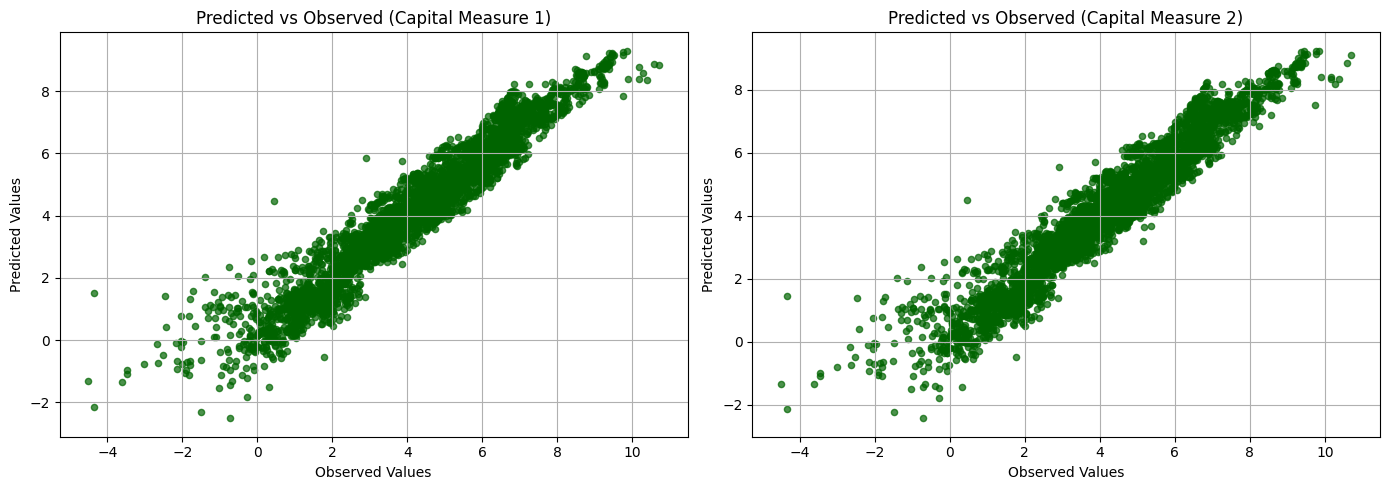

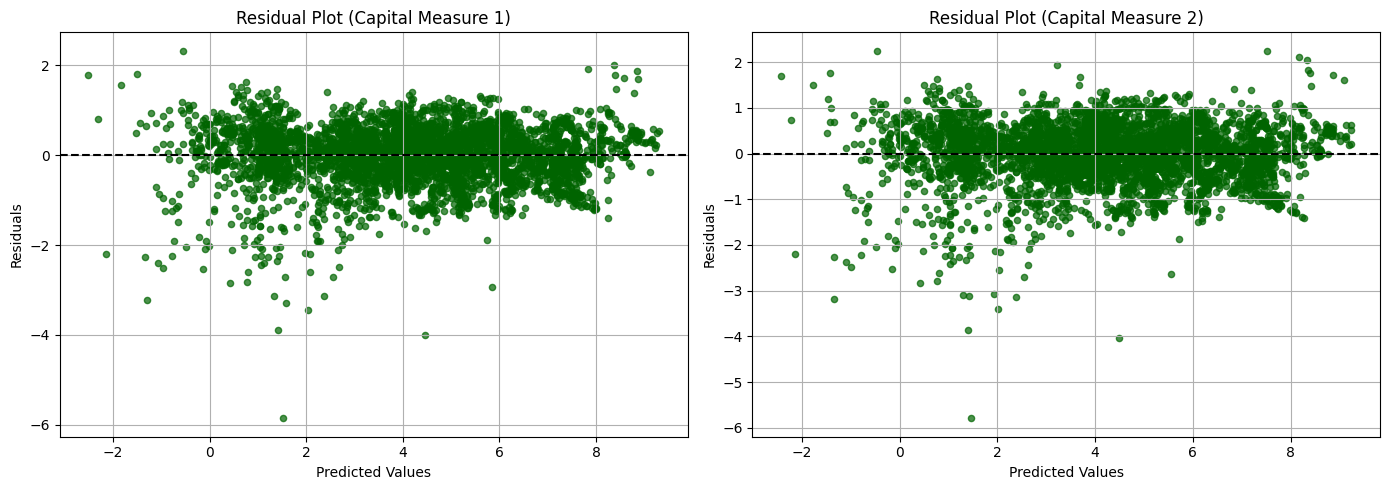

In [25]:
y_actual1 = capital1['Value Added']
y_actual2 = capital2['Value Added']

pred1 = ols1.predict(variables_to_include_ols1)
pred2 = ols2.predict(variables_to_include_ols2)

actuals_preds = [(capital1['Value Added'], pred1, 'Capital Measure 1'),
                 (capital2['Value Added'], pred2, 'Capital Measure 2')]

# Predicted vs Observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    ax.scatter(y_actual, y_pred, alpha=0.7, s=20, color='darkgreen')
    ax.set_title(f"Predicted vs Observed ({label})")
    ax.set_xlabel("Observed Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_actual, y_pred, label) in zip(axes, actuals_preds):
    residuals = y_actual - y_pred
    ax.scatter(y_pred, residuals, alpha=0.7, s=20, color='darkgreen')
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_title(f"Residual Plot ({label})")
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Residuals")
    ax.grid(True)

plt.tight_layout()
plt.show()

#### **Testing for Heteroscedasticity**

In [26]:
white_test = het_white(ols2.resid,  ols2.model.exog)
bp_test = het_breuschpagan(ols2.resid, ols2.model.exog)


In [27]:
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_test = dict(zip(labels, bp_test))
white_test = dict(zip(labels, white_test))

test = pd.DataFrame([bp_test, white_test], index=['BP Test', 'White Test'])
test[['LM Statistic', 'LM-Test p-value']]

,LM Statistic,LM-Test p-value
BP Test,56.342628,5.825775e-13
White Test,470.278387,2.072357e-99


LM-Test p-value indicates that there is heteroscedasticity.

#### **Identifying Heterogeneity**

In [28]:
data = financial_data.dropna()

In [29]:
unit = 'Ticker Symbol'
outcome = 'Value Added'

group_means = data.groupby(unit)[outcome].mean()
overall_mean = data[outcome].mean()

between_var = ((group_means - overall_mean) ** 2 * data.groupby(unit).size()).sum()
within_var = data.groupby(unit).apply(
    lambda group: ((group[outcome] - group[outcome].mean()) ** 2).sum()).sum()
total_var = ((data[outcome] - overall_mean) ** 2).sum()

print(f"Between-unit variation: {between_var / total_var:.2%}")
print(f"Within-unit variation: {within_var / total_var:.2%}")

Between-unit variation: 85.84%
Within-unit variation: 14.16%


Significant between-unit variation, indicating heterogeneity across units.

## **Model 2: Fixed Effects Models**

In [30]:
fixed_effects_model(capital1, 'Capital Measure 1')

Dep. Variable:,Value Added,R-squared:,0.4905
Estimator:,PanelOLS,R-squared (Between):,0.8709
No. Observations:,4327,R-squared (Within):,0.6265
Date:,"Tue, Apr 21 2026",R-squared (Overall):,0.8984
Time:,12:18:03,Log-likelihood,-606.48
Cov. Estimator:,Clustered,,
,,F-statistic:,1906.1
Entities:,306,P-value,0.0000
Avg Obs:,14.141,Distribution:,"F(2,3960)"
Min Obs:,1.0000,,
Max Obs:,53.000,F-statistic (robust):,275.35


In [31]:
fixed_effects_model(capital2, 'Capital Measure 2')

Dep. Variable:,Value Added,R-squared:,0.4692
Estimator:,PanelOLS,R-squared (Between):,0.8612
No. Observations:,4327,R-squared (Within):,0.6062
Date:,"Tue, Apr 21 2026",R-squared (Overall):,0.8864
Time:,12:18:04,Log-likelihood,-694.83
Cov. Estimator:,Clustered,,
,,F-statistic:,1750.6
Entities:,306,P-value,0.0000
Avg Obs:,14.141,Distribution:,"F(2,3960)"
Min Obs:,1.0000,,
Max Obs:,53.000,F-statistic (robust):,248.46


## **Model 3: Olley-Pakes**

Olley-Pakes use the following production function:

$$ y_{it} = \beta_0 + \beta_a a_{it} + \beta_k k_{it} + \beta_l l_{it} + \omega_{it} + \nu_{it} $$

where $y_{it}$ is the log of output (value added) from plant i at time t, $a_{it}$ its age, $k_{it}$ the log of its capital input, $l_{it}$ the log of its labor input, $\omega_{it}$ its productivity, and $\nu_{it}$ is either measurement error (which can be serially correlated) or a shock to productivity which is not forecastable during the period in which labor can be adjusted. Here both $\omega$ and $\nu$ are unobserved. The distinction is that $\omega$ is a state variable in the firm's decision problem, and hence a determinant of both liquidation and input demand decisions, while $\nu$ is not.

In [32]:
df_OP = capital2[['Ticker Symbol', 
                  'NAICS Industry',
                  'time',
                  'year',
                  'Total Employment',
                  'Employees_pred_lower', 
                  'Employees_pred_upper',
                  'Capital Measure 1',
                  'Capital Measure 2',
                  'Capital Expenditure',
                  'Revenue - Total',
                  'Cost of Goods Sold',
                  'Survival',
                  'Value Added']]

y = 'Value Added'
i = 'Capital Expenditure'
k = 'Capital Measure 2'
l = 'Total Employment'
t = 'time'

df_OP = df_OP.dropna().reset_index(drop=True)

In [33]:
df_OP = df_OP.sort_values(['Ticker Symbol', 'time']).copy()
g = df_OP.groupby('Ticker Symbol')
df_OP['y_next'] = g[y].shift(-1)
df_OP['l_next'] = g[l].shift(-1)
df_OP['k_next'] = g[k].shift(-1)

The "partially linear" model below: $$y_{it} = \beta_l l_{it} + \Phi_t(i_{it}, a_{it}, k_{it})+\Nu_{it}$$

is a semiparametric regression model (Engel, Granger, Rice, and Weiss (1986) and Robinson (1988)) which identifies $\beta_l$ but not the production function coefficients of capital and age, $\beta_a$ and $\beta_k$. That is, the equation does not allow us to separate the effect of capital and age on the investment decision from their effect on output. 

We estimate the partially linear model as follows:

In [34]:
cols_to_check = [y, i, k, l]
df_OP = df_OP.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_to_check)

OP_Stage1, X_poly_df, X, y_vec = OP_model.stage_1(df_OP, cols_to_check)
print(OP_Stage1.summary())

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     5439.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:04   Log-Likelihood:                -4023.1
No. Observations:                4327   AIC:                             8068.
Df Residuals:                    4316   BIC:                             8138.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

To identify $\beta_a$ and $\beta_k$ we use, in addition to the estimates of $\beta_l$ and $\Phi_t(\cdot)$ obtained from the partially linear model, estimates of the survival probabilities. These probabilities are given by: 

$$
\begin{aligned}
\quad \text{Pr} \{ \chi_{t+1} = 1 &| \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), J_t \} \\
&= \text{Pr} \{ \omega_{t+1} \geq \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}) | \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t \{ \underline{\omega}_{t+1}(k_{t+1}, a_{t+1}), \omega_t \} \\
&= \wp_t (i_t, a_t, k_t) \\
&\equiv P_t
\end{aligned}
$$

In [35]:
params = X_poly_df, X, l
df_OP, OP_probit_model, beta_l = OP_model.predict_survival_prob(df_OP, OP_Stage1, params)

Optimization terminated successfully.
         Current function value: 0.106868
         Iterations 7


In [36]:
OP_probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:               Survival   No. Observations:                 4327
Model:                         Probit   Df Residuals:                     4317
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                 0.01995
Time:                        12:18:04   Log-Likelihood:                -462.42
converged:                       True   LL-Null:                       -471.83
Covariance Type:            nonrobust   LLR p-value:                   0.02670
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                       1.8320      0.702      2.610      0.009       0.456       3.208
Capital Expenditure                         0.1610      0.477      0.337      0.736      -0.775       1.097
Capital Measure 2                          -0.1814      0.599     -0.303      0.762      -1.355       0.992
Capital Expenditure^2                       0.1941      0.142      1.371      0.170      -0.083       0.472
Capital Expenditure Capital Measure 2      -0.3358      0.314     -1.070      0.284      -0.951       0.279
Capital Measure 2^2                         0.1587      0.186      0.851      0.395      -0.207       0.524
Capital Expenditure^3                       0.0199      0.015      1.358      0.174      -0.009       0.049
Capital Expenditure^2 Capital Measure 2    -0.0667      0.047     -1.423      0.155      -0.159       0.025
Capital Expenditure Capital Measure 2^2     0.0666      0.051      1.296      0.195      -0.034       0.167
Capital Measure 2^3                        -0.0218      0.020     -1.115      0.265      -0.060       0.017
===========================================================================================================
"""

The third (and final) step of the estimation procedure takes the estimates of $\beta_l$, $\phi_t$, and $P_t$ from the first two steps, substitutes them into equation (12) for the true $\beta_l$, $\phi_t$, and $P_t$, and then obtains estimates of $(\beta_a, \beta_k)$, by minimizing the sum of squared residuals in that equation. Here we try both a series and a kernel estimator of the unknown $g(P_t, h_t)$ function. Recall that we estimate $\phi_t$ and $h_t = \phi_t - \beta_a a_t - \beta_k k_t$, so the values of the regressors that determine $g(\cdot)$ depend upon the values of the parameters of interest.

For the series estimator we used a fourth order polynomial expansion in $(P_t, h_t)$ (and again there was almost no difference in either the sum of squares, or in the coefficients of interest, between the third and the fourth order approximation). Thus the series estimator is obtained by running nonlinear least squares on the equation

$$
\quad y_{t+1} - b_l l_{t+1} = c + \beta_a a_{t+1} + \beta_k k_{t+1} + \sum_{j=0}^{4-m} \sum_{m=0}^{4} \beta_{mj} \hat{h}_t^m \hat{P}_t^j + e_t
$$

with 

$$
\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t.
$$

Here $\hat{\phi}_t$ and $b_l$ are taken from the estimates of the partially linear model in (8), and $\hat{P}_t$ is taken from the kernel estimates of the survival probability in (10).

The kernel estimator is obtained by forming a kernel estimator of the regression of 

$$
y_{t+1} - b_l l_{t+1} - \beta_a a_{t+1} - \beta_k k_{t+1}
$$

on $\hat{P}_t$ and $\hat{h}_t = \hat{\phi}_t - \beta_a a_t - \beta_k k_t$, for different values of $(\beta_a, \beta_k)$, and then using a nonlinear search routine to find that value of $(\beta_a, \beta_k)$ that minimized the sum of squared residuals from this regression. Again the results are the bias reducing kernels in Bierens (1987) (though we also used a standard normal kernel with little difference in the resulting coefficient estimates).$^{23}$

In [37]:
params = 'Value Added', k, l
beta_k_final, df = OP_model.stage_2(df_OP, params, beta_l)

Estimated Beta_K: 0.6240225766749226


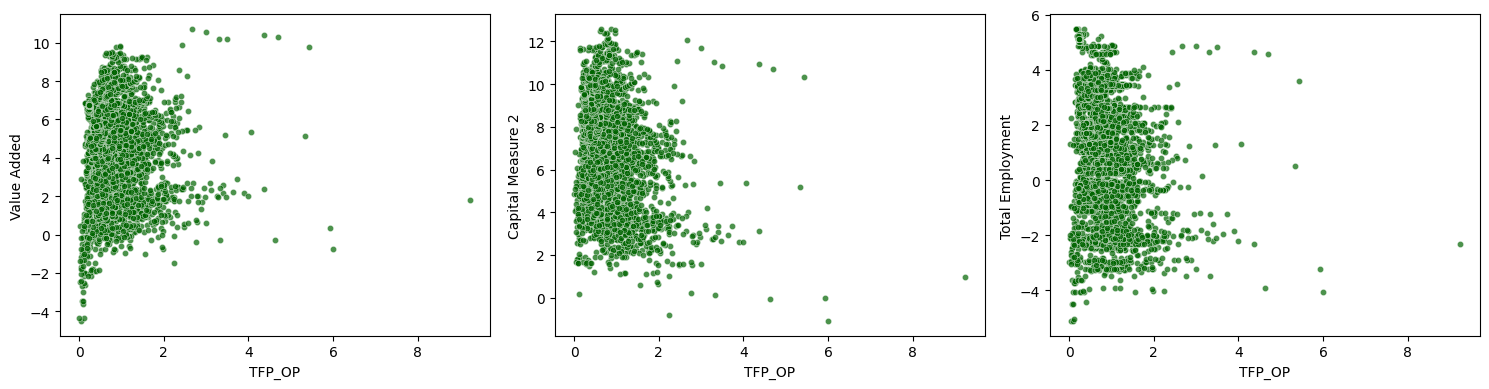

In [38]:
pair_plot_df = df_OP[['Value Added',
                      k,
                      l,
                      'TFP_OP']]

pair_plot_df = pair_plot_df.reset_index()
pair_plot_df.drop(columns={'index'}, inplace=True)

main_var = 'TFP_OP'
other_vars = [col for col in pair_plot_df.columns if col != main_var]

fig, axes = plt.subplots(1, len(other_vars), figsize=(5 * len(other_vars), 4))
if len(other_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, other_vars):
    
    sns.scatterplot(x=pair_plot_df[main_var], y=pair_plot_df[var], alpha=0.7, s=20, color='darkgreen', ax=ax)
    ax.set_xlabel(main_var)
    ax.set_ylabel(var)

plt.tight_layout()
plt.show()

In [39]:
decomposition_df, OP_decomp = decomposition(df_OP, 'TFP_OP')

In [40]:
print(decomposition_df)

      unweighted_mean_p  weighted_mean_p  covariance_term
year                                                     
2010          -0.138323        -0.152813        -0.014489
2011          -0.217888        -0.250683        -0.032795
2012          -0.380319        -0.345623         0.034695
2013          -0.231462        -0.279719        -0.048257
2014          -0.231307        -0.287241        -0.055935
2015          -0.356780        -0.355138         0.001642
2016          -0.314365        -0.313655         0.000709
2017          -0.265235        -0.262369         0.002867
2018          -0.260288        -0.256498         0.003790
2019          -0.375673        -0.363924         0.011749
2020          -0.376395        -0.353942         0.022453
2021          -0.413901        -0.245577         0.168324
2022          -0.379083        -0.307920         0.071163
2023          -0.449867        -0.376698         0.073169
2024          -0.485382        -0.389076         0.096306
2025          

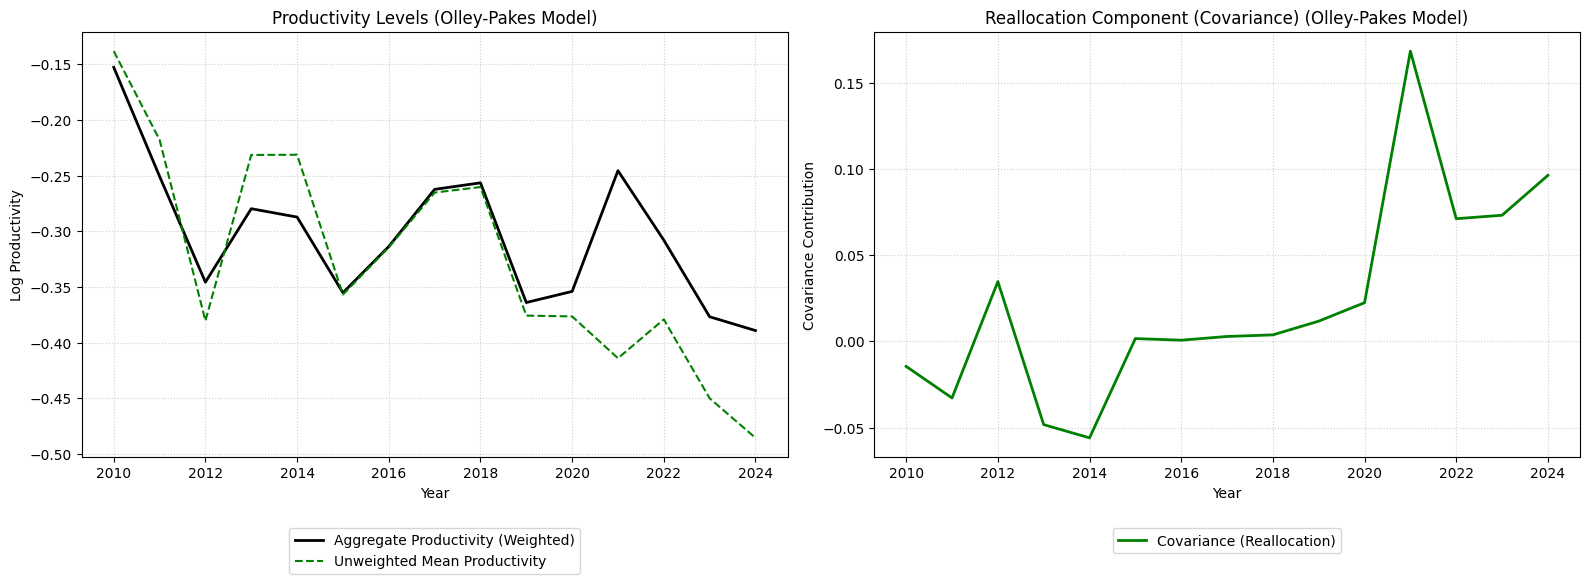

In [41]:
TFP_plot(decomposition_df, 'Olley-Pakes Model')

In [42]:
decomp_cols = ['year', 'time', 'Ticker Symbol', 'NAICS Industry', 'TFP_OP', 'Revenue - Total', 'cov_contribution']
OP_decomp[decomp_cols].to_csv(f'{parent_dir}/output/TFP/Quarterly/TFP_OP.csv')

In [43]:
params = k, l, beta_l, beta_k_final
OP_model.invertibility_test(df_OP, params)

--- Robustness Test Results (Section 4.1) ---
Original Beta_K: 0.6240
Robust Beta_K:   0.8418
Gamma_L (Coeff on Lagged Labor): -0.4386
FAIL: Gamma_L is large. Labor might be determining investment decisions.


In [44]:
stage1_params = ('Value Added', i, k, l)
stage2_params = ('Value Added', k, l)
k_iqr, l_iqr = OP_model.OP_bootstrap(df_OP, stage1_params, stage2_params, n_bootstraps=50)

Optimization terminated successfully.
         Current function value: 0.107732
         Iterations 8
Iter 1: k=0.732, l=0.280
Optimization terminated successfully.
         Current function value: 0.107238
         Iterations 8
Iter 2: k=0.666, l=0.345
Optimization terminated successfully.
         Current function value: 0.101208
         Iterations 8
Iter 3: k=0.535, l=0.369
Optimization terminated successfully.
         Current function value: 0.110254
         Iterations 8
Iter 4: k=0.698, l=0.359
Optimization terminated successfully.
         Current function value: 0.099619
         Iterations 8
Iter 5: k=0.646, l=0.242
Optimization terminated successfully.
         Current function value: 0.101540
         Iterations 7
Iter 6: k=0.678, l=0.294
Optimization terminated successfully.
         Current function value: 0.112205
         Iterations 8
Iter 7: k=0.541, l=0.356
Optimization terminated successfully.
         Current function value: 0.094502
         Iterations 8
Iter 8: k

## **Model 4: ACKERBERG-CAVES-FRAZER Model**

We estimate the following Leontief-derived value-added production function:

$$Y_{it} = \beta_0 K^{\beta_{k}}_{it} L^{\beta_{l}}_{it} e^{\omega_{it}} e^{\epsilon_{it}}$$

When we use the ACF procedure, we use $M_{it}$ to invert the productivity shock.

In [45]:
ACF_df = capital2[['Ticker Symbol',
                    'NAICS Industry',
                    'time',
                    'year',
                    'Revenue - Total',
                    'Total Employment',
                    'Employees_pred_lower', 
                    'Employees_pred_upper',
                    'Capital Measure 2', 
                    'Inventory - Raw Materials',
                    'Cost of Goods Sold',
                    'Value Added']]

ACF_df = ACF_df.dropna().reset_index(drop=True)

In [46]:
k = 'Capital Measure 2'
m = 'Inventory - Raw Materials'
l = 'Total Employment'
y = 'Value Added'
t = 'time'

For our procedure, our first stage is simply OLS of yit on $k_{it}$, $l_{lt}$, and $m_{it}$. More generally, one would want higher order polynomials in the explanatory variables, but because, in our setup, optimal $m_{it}$ is actually a linear function of $k_{it}$ > $l_{it}$, and $\omega_{it}$ we simply use a first order polynomial.

In [47]:
params = (y, k, l, m, t)

ACF_stage1 = ACF_model.stage_1(ACF_df, params)
print(ACF_stage1.summary())

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     1000.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:06   Log-Likelihood:                -3258.1
No. Observations:                4327   AIC:                             6674.
Df Residuals:                    4248   BIC:                             7178.
Df Model:                          78                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In the second stage, our estimation is based on the following moments (where $\tilde{\beta}_0$ = ln($\beta_0$)):

\begin{equation}
E \left[
\begin{aligned}
    & \left( y_{it} - \widetilde{\beta}_0 - \beta_k k_{it} - \beta_l l_{it} \right. \\
    & \quad \left. - \rho \cdot \left( \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1}) - \widetilde{\beta}_0 - \beta_k k_{it-1} - \beta_l l_{it-1} \right) \right) \\
    & \otimes \begin{pmatrix}
        1 \\
        k_{it} \\
        l_{it-1} \\
        \widetilde{\Phi}_{t-1}(k_{it-1}, l_{it-1}, m_{it-1})
    \end{pmatrix}
\end{aligned}
\right] = 0.
\tag{40}
\end{equation}

In [48]:
ACF_df['phi_hat'] = ACF_stage1.fittedvalues

In [49]:
params = y, k, l
beta_k_est, beta_l_est, df_full, df_stage2 = ACF_model.stage_2(ACF_df, params, ACF_stage1)
print(f"Full sample: beta_k={beta_k_est:.4f}, beta_l={beta_l_est:.4f}")

x0=[0.2,0.4] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.2,0.6] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.2,0.8] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.2,1.0] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.2,1.2] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.3,0.4] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.3,0.6] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.3,0.8] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.3,1.0] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.3,1.2] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.4,0.4] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.4,0.6] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.4,0.8] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.4,1.0] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.4,1.2] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.5,0.4] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.5,0.6] -> k=0.6890, l=0.2551, obj=0.00006000
x0=[0.5,0.8] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.5,1.0] -> k=0.4179, l=1.0750, obj=0.00023579
x0=[0.5,1.2] -> k=0.4179, l=1.0

In [50]:
ACF_df['ln_TFP'] = ACF_df['phi_hat'] - (beta_k_est * ACF_df[k]) - (beta_l_est * ACF_df[l])
ACF_df['ln_TFP'].describe()

count    4327.000000
mean       -0.642130
std         0.390508
min        -5.709974
25%        -0.781765
50%        -0.607410
75%        -0.437664
max         1.830580
Name: ln_TFP, dtype: float64

In [51]:
rho_params = k, l, beta_k_est, beta_l_est
ACF_model.calculate_rho(df_stage2, rho_params)

Estimated Rho: 0.8509


np.float64(0.850883471327466)

In [52]:
boot_params = y, k, l, m
acf.bootstrap_se(ACF_df, boot_params, impute_labor=True, n_bootstraps=50)

Iter 1: k=0.897, l=0.216
Iter 2: k=0.759, l=0.195
Iter 3: k=0.840, l=0.247
Iter 4: k=0.894, l=0.355
Iter 5: k=0.974, l=0.366
Iter 6: k=1.156, l=0.421
Iter 7: k=0.892, l=0.261
Iter 8: k=0.934, l=0.345
Iter 9: k=0.826, l=0.122
Iter 10: k=0.472, l=0.133
Iter 11: k=0.804, l=0.233
Iter 12: k=0.859, l=0.324
Iter 13: k=0.890, l=0.258
Iter 14: k=0.361, l=0.186
Iter 15: k=0.822, l=0.310
Iter 16: k=0.921, l=0.344
Iter 17: k=0.919, l=0.325
Iter 18: k=0.920, l=0.332
Iter 19: k=0.882, l=0.273
Iter 20: k=1.022, l=0.319
Iter 21: k=0.942, l=0.302
Iter 22: k=0.940, l=0.397
Iter 23: k=0.755, l=0.163
Iter 24: k=0.791, l=0.188
Iter 25: k=0.841, l=0.309
Iter 26: k=0.852, l=0.068
Iter 27: k=1.048, l=0.233
Iter 28: k=0.781, l=0.193
Iter 29: k=0.819, l=0.210
Iter 30: k=0.910, l=0.221
Iter 31: k=0.798, l=0.160
Iter 32: k=0.898, l=0.189
Iter 33: k=0.981, l=0.198
Iter 34: k=0.995, l=0.318
Iter 35: k=0.937, l=0.294
Iter 36: k=0.866, l=0.332
Iter 37: k=0.800, l=0.136
Iter 38: k=0.886, l=0.297
Iter 39: k=0.860, l=0

(np.float64(0.07953576772127305), np.float64(0.09173865718821504))

In [53]:
ACF_df['TFP_ACF'] = np.exp(ACF_df['ln_TFP'])
ACF_agg, ACF_firm = decomposition(ACF_df, 'TFP_ACF')

In [54]:
decomp_cols = ['year', 'time', 'Ticker Symbol', 'NAICS Industry', 'ln_TFP', 'Revenue - Total', 'cov_contribution']
ACF_firm[decomp_cols].to_csv(f'{parent_dir}/output/TFP/Quarterly/TFP_ACF.csv')

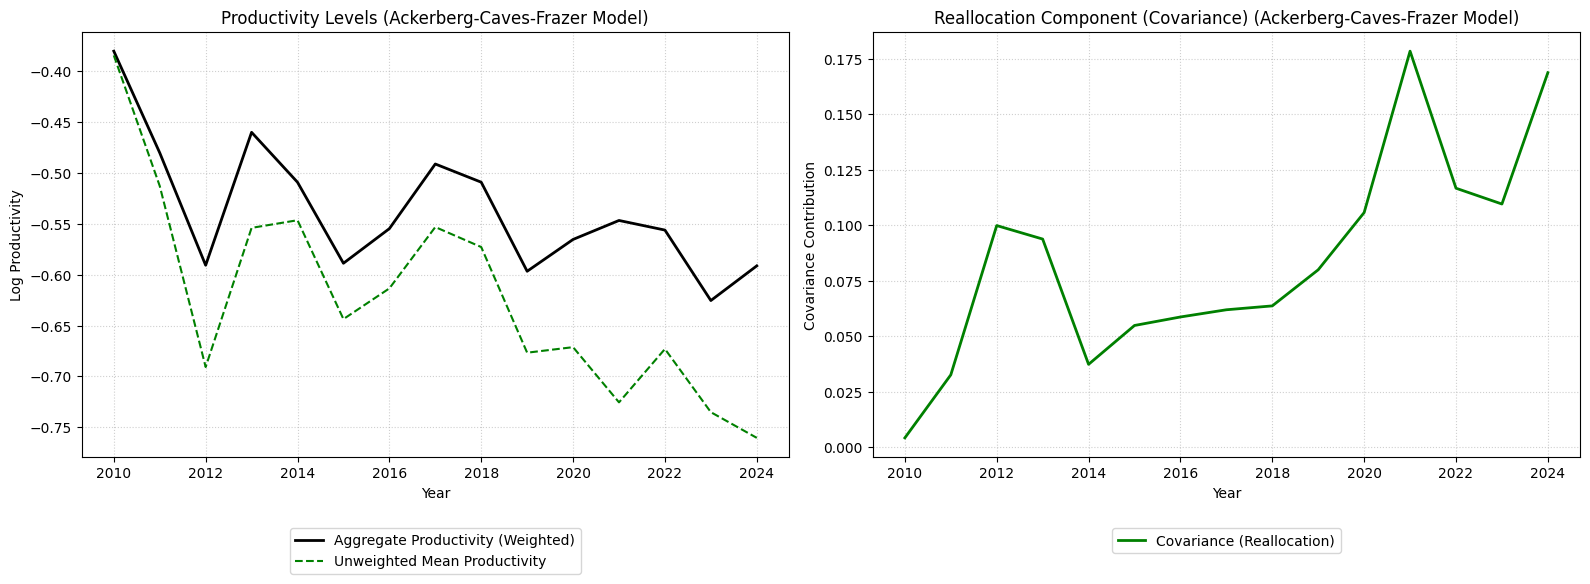

In [55]:
TFP_plot(ACF_agg, 'Ackerberg-Caves-Frazer Model')

### **ACKERBERG-CAVES-FRAZER Model Split by Year**

#### ***For Years Prior to 2017***

In [56]:
y, k, l, m, t = 'Value Added', 'Total Employment', 'Capital Measure 2', 'Inventory - Raw Materials', 'time'

ACF_COLUMNS = ['Ticker Symbol', 'NAICS Industry', 'time', 'year',
                'Revenue - Total', 'Total Employment',
                'Employees_pred_lower', 'Employees_pred_upper',
                'Capital Measure 2', 'Inventory - Raw Materials',
                'Cost of Goods Sold', 'Value Added']

# Pre-2017 cohort
ACF_df_y1 = acf.prepare_acf_df(capital2, ACF_COLUMNS, year_cutoff=2017, before=True)

In [57]:
stage1_params = (y, k, l, m, t)
stage2_params = (y, k, l)
boot_params   = (y, k, l, m)

In [58]:
stage1_model_y1, ACF_df_y1 = acf.run_stage1(ACF_df_y1, stage1_params)

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     759.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:09   Log-Likelihood:                -1043.3
No. Observations:                1585   AIC:                             2177.
Df Residuals:                    1540   BIC:                             2418.
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [59]:
print(ACF_df_y1['time'].dtype)
print(ACF_df_y1['time'].nunique())
print(ACF_df_y1['time'].describe())

int64
26
count    1585.000000
mean       15.877603
std         7.002717
min         2.000000
25%        10.000000
50%        16.000000
75%        22.000000
max        27.000000
Name: time, dtype: float64


In [60]:
beta_k_y1, beta_l_y1, df_full_y1, df_stage2_y1 = acf.run_stage2(ACF_df_y1, stage2_params, stage1_model_y1)

x0=[0.2,0.4] -> k=0.2836, l=0.2594, obj=0.00000774
x0=[0.2,0.6] -> k=0.1018, l=0.7510, obj=0.00000085
x0=[0.2,0.8] -> k=0.1018, l=0.7510, obj=0.00000085
x0=[0.2,1.0] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.2,1.2] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.3,0.4] -> k=0.2836, l=0.2594, obj=0.00000774
x0=[0.3,0.6] -> k=0.2836, l=0.2594, obj=0.00000774
x0=[0.3,0.8] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.3,1.0] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.3,1.2] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.4,0.4] -> k=0.2836, l=0.2594, obj=0.00000774
x0=[0.4,0.6] -> k=0.8490, l=-0.7780, obj=0.00001479
x0=[0.4,0.8] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.4,1.0] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.4,1.2] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.5,0.4] -> k=0.2836, l=0.2594, obj=0.00000774
x0=[0.5,0.6] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.5,0.8] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.5,1.0] -> k=0.7966, l=0.6761, obj=0.00062799
x0=[0.5,1.2] -> k=0.7966, l=0.

In [61]:
ACF_df_y1 = acf.compute_ln_tfp(ACF_df_y1, k, l, beta_k_y1, beta_l_y1)

count    1585.000000
mean       -0.902289
std         0.420218
min        -6.130778
25%        -1.072634
50%        -0.866937
75%        -0.650034
max         0.531646
Name: ln_TFP, dtype: float64


In [62]:
acf.compute_rho(df_stage2_y1, k, l, beta_k_y1, beta_l_y1)

Estimated Rho: 0.9051


np.float64(0.9050502434472475)

In [63]:
acf.bootstrap_se(ACF_df_y1, boot_params, impute_labor=True, n_bootstraps=50)

Iter 1: k=0.976, l=0.075
Iter 2: k=0.733, l=0.124
Iter 3: k=0.666, l=0.096
Iter 4: k=0.262, l=0.132
Iter 5: k=0.577, l=0.100
Iter 6: k=0.579, l=0.053
Iter 7: k=0.650, l=0.064
Iter 8: k=0.449, l=0.090
Iter 9: k=1.111, l=0.001
Iter 10: k=0.900, l=0.054
Iter 11: k=0.415, l=0.118
Iter 12: k=0.502, l=0.124
Iter 13: k=1.074, l=0.114
Iter 14: k=1.116, l=0.010
Iter 15: k=1.038, l=0.042
Iter 16: k=0.658, l=0.091
Iter 17: k=1.189, l=0.042
Iter 18: k=0.986, l=0.048
Iter 19: k=0.482, l=0.106
Iter 20: k=0.862, l=0.048
Iter 21: k=1.095, l=0.015
Iter 22: k=1.064, l=0.022
Iter 23: k=1.079, l=0.026
Iter 24: k=1.005, l=0.051
Iter 25: k=0.699, l=0.083
Iter 26: k=1.058, l=0.045
Iter 27: k=0.689, l=0.103
Iter 28: k=0.893, l=0.050
Iter 29: k=1.028, l=0.045
Iter 30: k=1.127, l=-0.007
Iter 31: k=0.381, l=0.133
Iter 32: k=1.084, l=-0.032
Iter 33: k=1.103, l=0.029
Iter 34: k=0.632, l=0.034
Iter 35: k=1.005, l=0.059
Iter 36: k=0.854, l=0.036
Iter 37: k=1.102, l=0.020
Iter 38: k=0.337, l=0.123
Iter 39: k=1.126, l

(np.float64(0.41970064503721854), np.float64(0.0387882604053702))

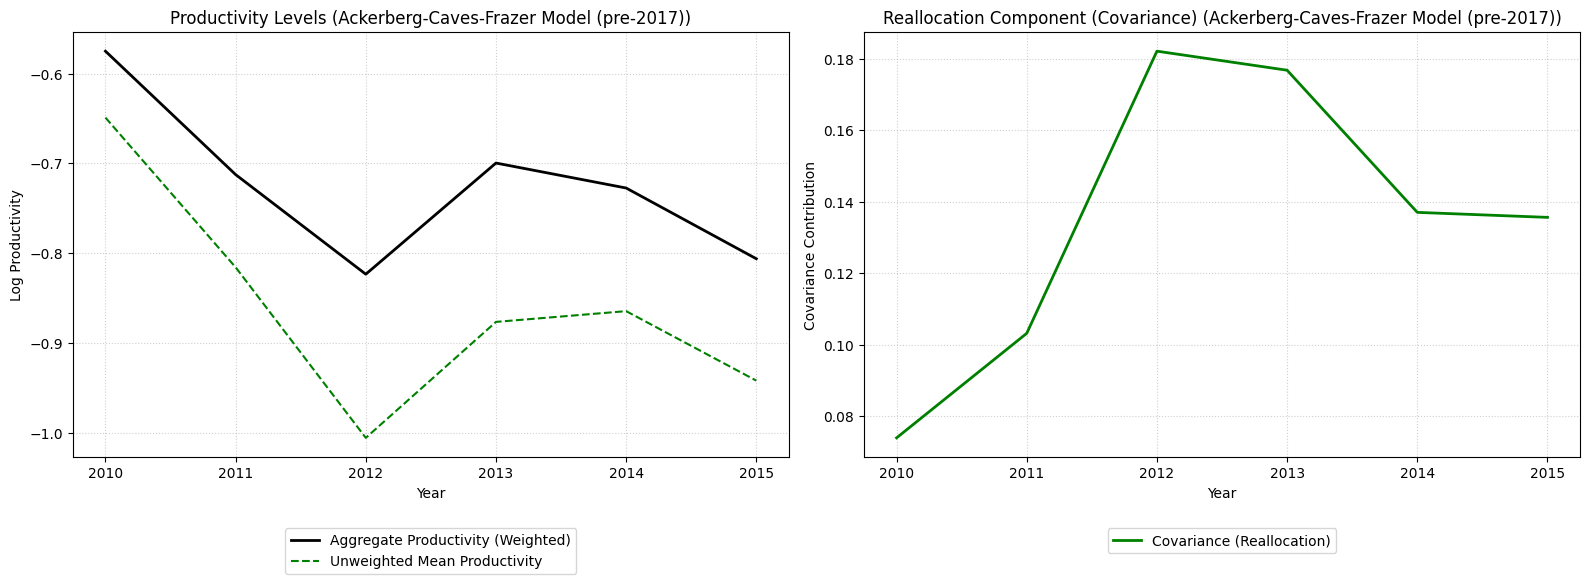

In [64]:
DECOMP_COLS = ['year', 'time', 'Ticker Symbol', 'NAICS Industry',
               'ln_TFP', 'Revenue - Total', 'cov_contribution']

agg_y1, firm_y1 = acf.decompose_and_plot(
    ACF_df_y1, DECOMP_COLS,
    label='Ackerberg-Caves-Frazer Model (pre-2017)',
    output_path=acf.PARENT_DIR / 'output' / 'TFP' / 'Quarterly' / 'TFP_ACF_y1.csv',
)

#### ***For Years After 2017***

In [65]:
y, k, l, m, t = 'Value Added', 'Total Employment', 'Capital Measure 2', 'Inventory - Raw Materials', 'time'

# Post-2017 cohort
ACF_df_y2 = acf.prepare_acf_df(capital2, ACF_COLUMNS, year_cutoff=2017, before=False)

In [66]:
stage1_params = (y, k, l, m, t)
stage2_params = (y, k, l)
boot_params   = (y, k, l, m)

In [67]:
stage1_model_y2, ACF_df_y2 = acf.run_stage1(ACF_df_y2, stage1_params)

                            OLS Regression Results                            
Dep. Variable:            Value Added   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     897.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:10   Log-Likelihood:                -2160.2
No. Observations:                2742   AIC:                             4426.
Df Residuals:                    2689   BIC:                             4740.
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [68]:
print(ACF_df_y2['time'].dtype)
print(ACF_df_y2['time'].nunique())
print(ACF_df_y2['time'].describe())

int64
34
count    2742.000000
mean       43.695113
std         8.885200
min        28.000000
25%        36.000000
50%        44.000000
75%        51.000000
max        61.000000
Name: time, dtype: float64


In [69]:
beta_k_y2, beta_l_y2, df_full_y2, df_stage2_y2 = acf.run_stage2(ACF_df_y2, stage2_params, stage1_model_y2)

x0=[0.2,0.4] -> k=1.0183, l=-0.1523, obj=0.00000843
x0=[0.2,0.6] -> k=1.0183, l=-0.1523, obj=0.00000843
x0=[0.2,0.8] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.2,1.0] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.2,1.2] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.3,0.4] -> k=1.0183, l=-0.1523, obj=0.00000843
x0=[0.3,0.6] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.3,0.8] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.3,1.0] -> k=1.0183, l=-0.1523, obj=0.00000843
x0=[0.3,1.2] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.4,0.4] -> k=1.0183, l=-0.1523, obj=0.00000843
x0=[0.4,0.6] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.4,0.8] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.4,1.0] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.4,1.2] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.5,0.4] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.5,0.6] -> k=0.3810, l=0.5947, obj=0.00002533
x0=[0.5,0.8] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.5,1.0] -> k=1.0774, l=0.7042, obj=0.00063471
x0=[0.5,1.2] -> k=1.0774, 

In [70]:
acf.compute_rho(df_stage2_y2, k, l, beta_k_y2, beta_l_y2)

Estimated Rho: 0.9607


np.float64(0.9607354007835109)

In [71]:
acf.bootstrap_se(ACF_df_y2, boot_params, impute_labor=True, n_bootstraps=50)

Iter 1: k=0.698, l=0.064
Iter 2: k=0.808, l=0.006
Iter 3: k=0.747, l=0.072
Iter 4: k=0.893, l=0.041
Iter 5: k=0.500, l=0.135
Iter 6: k=0.786, l=0.058
Iter 7: k=0.819, l=0.023
Iter 8: k=0.835, l=0.011
Iter 9: k=0.733, l=0.090
Iter 10: k=0.660, l=0.056
Iter 11: k=0.662, l=0.073
Iter 12: k=0.926, l=-0.005
Iter 13: k=0.850, l=0.067
Iter 14: k=0.826, l=0.040
Iter 15: k=0.802, l=-0.018
Iter 16: k=0.610, l=0.063
Iter 17: k=0.625, l=0.061
Iter 18: k=0.688, l=0.094
Iter 19: k=0.536, l=0.052
Iter 20: k=1.136, l=0.015
Iter 21: k=0.678, l=0.036
Iter 22: k=0.843, l=0.022
Iter 23: k=0.618, l=0.103
Iter 24: k=1.026, l=0.002
Iter 25: k=0.631, l=0.105
Iter 26: k=0.588, l=0.060
Iter 27: k=1.064, l=0.021
Iter 28: k=0.823, l=0.025
Iter 29: k=0.893, l=0.000
Iter 30: k=1.088, l=0.026
Iter 31: k=0.775, l=0.034
Iter 32: k=0.775, l=0.051
Iter 33: k=0.791, l=0.030
Iter 34: k=0.525, l=0.034
Iter 35: k=0.754, l=0.063
Iter 36: k=0.822, l=0.015
Iter 37: k=1.043, l=0.006
Iter 38: k=0.455, l=0.094
Iter 39: k=1.015, l

(np.float64(0.15200886399962713), np.float64(0.035688603911844745))

count    2742.000000
mean        4.486238
std         0.743747
min         0.859161
25%         3.950521
50%         4.469155
75%         4.938876
max         6.914959
Name: ln_TFP, dtype: float64


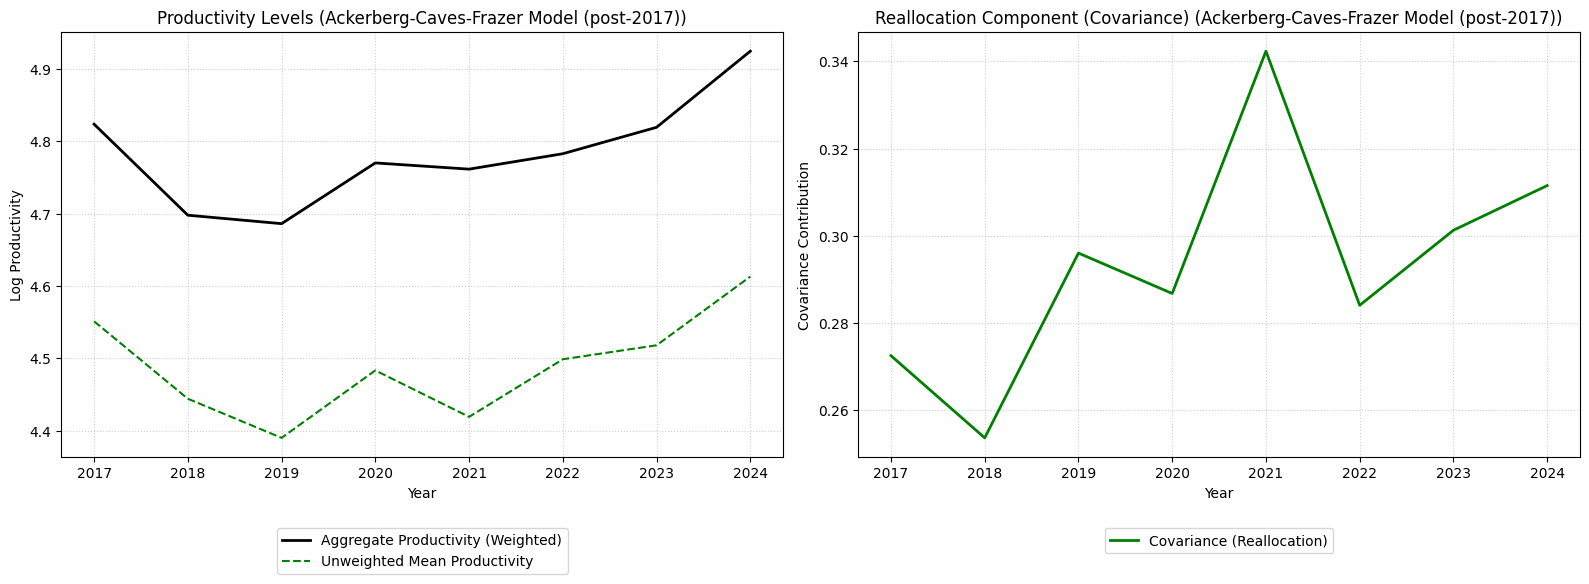

In [72]:
ACF_df_y2 = acf.compute_ln_tfp(ACF_df_y2, k, l, beta_k_y2, beta_l_y2)

agg_y2, firm_y2 = acf.decompose_and_plot(
    ACF_df_y2, DECOMP_COLS,
    label='Ackerberg-Caves-Frazer Model (post-2017)',
    output_path=acf.PARENT_DIR / 'output' / 'TFP' / 'Quarterly' / 'TFP_ACF_y2.csv',
)